In [2]:
import random
import pandas as pd
from cubes.construct.buildingconfig import load_building_config
from cubes.construct.building import Building
from cubes.package.envconfig import EnvConfig
from cubes.package.simple_simulation import prepare_simulation


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [5]:
bc_file_path = "/workspaces/CUBES/exp/jack/paper/zoning_experiment/input/case_0_0.json"
files_dir = "/workspaces/CUBES/exp/jack/paper/zoning_experiment/files_dir"

BC = load_building_config(bc_file_path, files_dir=files_dir)

def create_random_buildingconfigs(BC):

    for n in range(5):
        occ_filename = f"schedule_rep_{n}.sch"
        BC.ocupant_schedule_file_name = occ_filename

        for m in range(10):

            # Original list
            original_zone_names = BC.zone_names
            num = len(original_zone_names[0])

            # shuffle zones
            new_zone_names = random.sample(original_zone_names[0], num)

            # Generate a list of length 5 with random numbers between 0 and 5
            controlled_zone_index = random.randint(0, num-1)

            BC.zone_names = [new_zone_names]
            BC.controlled_zones = [new_zone_names[controlled_zone_index]]

            BC.gas_pricing_file_name = "csv_gastracker_A_Eastern_England_2022.csv"
            BC.electricity_pricing_file_name = "csv_agile_A_Eastern_England_2022.csv"

            BC.fridge_compressor_refrigerant = ""

            BC.save_to_file(f"/workspaces/CUBES/exp/jack/paper/zoning_experiment/input/rep{n}/case0_iter{m}.json")

In [6]:
create_random_buildingconfigs(BC)

In [1]:

materials = pd.read_pickle("/workspaces/CUBES/cubes/materials.pickle")
windows = pd.read_pickle("/workspaces/CUBES/cubes/windows.pickle")

BC = load_building_config(bc_file_path, files_dir=files_dir)
EC = EnvConfig(files_dir=files_dir)
building=Building(BC,materials,windows)
#building=Building(BC,materials_evaluator(),windows_evaluator())
building.build()
idf = building.get_idf()


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


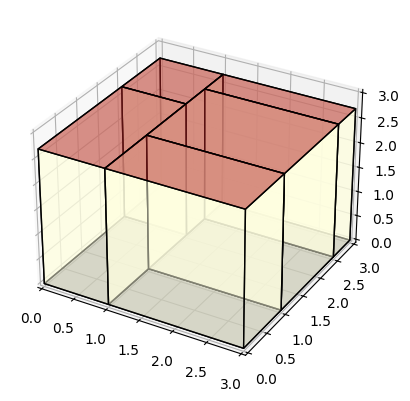

In [2]:
idf.view_model()

In [8]:
EC = EnvConfig(files_dir=files_dir)
idf = prepare_simulation(idf, BC, EC)

idf.run(output_directory= "/workspaces/CUBES/exp/jack/paper/output",
        expandobjects=True,
        readvars=True,
        weather="/workspaces/CUBES/cubes/data/weather/Cambridgeshire_CC_2022.epw",
        verbose="q",
    )
